# Problem 1: Square of Standard Normal

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ncf

In [2]:
def generate_ratio(N = 500_000, a = 2):
    xs = np.random.normal(0, 1, N)
    w = np.array([x ** 2 for x in xs])
    result = np.array([i for i in w if i <= a])
    return len(result) / N

In [3]:
ratios = np.array([generate_ratio() for i in range(10)])

In [4]:
print(f'Min: {min(ratios)}, Max: {max(ratios)}')
print(f'{min(ratios)} < 0.8427 < {max(ratios)}')

Min: 0.841588, Max: 0.84305
0.841588 < 0.8427 < 0.84305


## a = 3

In [5]:
ratios = np.array([generate_ratio(500_000, 3) for i in range(10)])

print(f'Min: {min(ratios)}, Max: {max(ratios)}')
print(f'{min(ratios)} < 0.9167 < {max(ratios)}')

Min: 0.915826, Max: 0.917254
0.915826 < 0.9167 < 0.917254


## a = 0.001

In [6]:
ratios = np.array([generate_ratio(500_000, 0.001) for i in range(10)])

print(f'Min: {min(ratios)}, Max: {max(ratios)}')
print(f'{min(ratios)} < 0.02523 < {max(ratios)}')

Min: 0.024998, Max: 0.025594
0.024998 < 0.02523 < 0.025594


# Problem 2: Central Limit Theorem

$X :=
\begin{cases} 
      \text{Unif}[0, 5] &\text{if HH} \\
      9 &\text{if HT} \\
      25 &\text{if TH, TT} \\
   \end{cases}
$

In [7]:
def generate_coin():
    coin = np.random.randint(0, 2, 2)
    if (coin[0] == 0 and coin[1] == 0):
        return np.random.uniform(0, 5)
    elif (coin[0] == 0 and coin[1] == 1):
        return 9
    else: return 25

In [8]:
simulation = [generate_coin() for i in range(1000)]

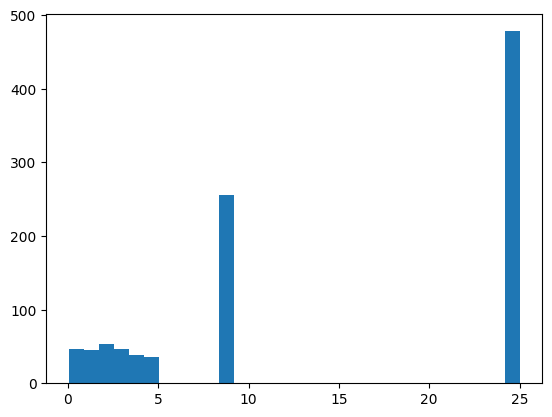

In [9]:
plt.hist(simulation, bins = 30);

In [10]:
def generate_y(n = 30):
    xs = [generate_coin() for i in range(n)]
    Y = sum(xs) / n
    return Y

In [11]:
ys = [generate_y() for i in range(30000)]

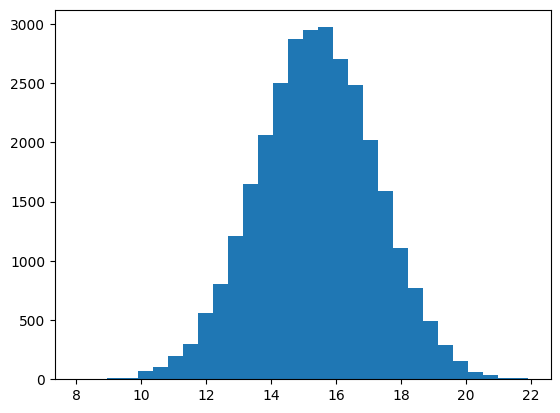

In [12]:
plt.hist(ys, bins = 30);

# Problem 3: Noncentral Chi-Squared

## 3.1

In [13]:
def generate_chi(a, b, c, d, e, f):
    A = np.random.normal(a, 1)
    B = np.random.normal(b, 1)
    C = np.random.normal(c, 1)
    D = np.random.normal(d, 1)
    E = np.random.normal(e, 1)
    F = np.random.normal(f, 1)
    X = A ** 2 + B ** 2 + C ** 2
    Y = D ** 2 + E ** 2 + F ** 2
    return (X, Y)

In [14]:
N = 50000
pairs = [generate_chi(7, 7, 2, 10, 1, 1) for i in range(N)]
xs = [pairs[i][0] for i in range(len(pairs))]
ys = [pairs[i][1] for i in range(len(pairs))]

In [15]:
print(f'For X:\n')
print(f'10%: {np.quantile(xs, 0.1)}')
print(f'30%: {np.quantile(xs, 0.3)}')
print(f'50%: {np.quantile(xs, 0.5)}')
print(f'70%: {np.quantile(xs, 0.7)}')
print(f'90%: {np.quantile(xs, 0.9)}')

print(f'For Y:\n')
print(f'10%: {np.quantile(ys, 0.1)}')
print(f'30%: {np.quantile(ys, 0.3)}')
print(f'50%: {np.quantile(ys, 0.5)}')
print(f'70%: {np.quantile(ys, 0.7)}')
print(f'90%: {np.quantile(ys, 0.9)}')

print('Similar')

For X:

10%: 79.54292603825446
30%: 93.51841978609897
50%: 104.004433902635
70%: 114.92050470422355
90%: 131.8081415535898
For Y:

10%: 79.62397539456182
30%: 93.38768107852844
50%: 103.9651471605655
70%: 114.86288903046827
90%: 131.7715815102972
Similar


## 3.2

In [16]:
N = 50000
pairs = [generate_chi(7, 7, 2, 10, 5, 1) for i in range(N)]
xs = [pairs[i][0] for i in range(len(pairs))]
ys = [pairs[i][1] for i in range(len(pairs))]

print(f'For X:\n')
print(f'10%: {np.quantile(xs, 0.1)}')
print(f'30%: {np.quantile(xs, 0.3)}')
print(f'50%: {np.quantile(xs, 0.5)}')
print(f'70%: {np.quantile(xs, 0.7)}')
print(f'90%: {np.quantile(xs, 0.9)}')

print(f'For Y:\n')
print(f'10%: {np.quantile(ys, 0.1)}')
print(f'30%: {np.quantile(ys, 0.3)}')
print(f'50%: {np.quantile(ys, 0.5)}')
print(f'70%: {np.quantile(ys, 0.7)}')
print(f'90%: {np.quantile(ys, 0.9)}')

print('Different now')

For X:

10%: 79.8941190836698
30%: 93.70051449450796
50%: 103.9350136765571
70%: 114.74730467771381
90%: 131.39916756118114
For Y:

10%: 100.75880484147159
30%: 116.35895793703027
50%: 128.01988621325518
70%: 139.9655221647892
90%: 158.2982877788073
Different now


# Problem 4: Noncentral F

In [17]:
def generate_w(x, y, z):
    xs = np.random.normal(x, 1, 3)
    ys = np.random.normal(y, 1, 5)
    zs = np.random.normal(z, 1, 7)
    
    W = ((sum(xs ** 2) + sum(ys ** 2)) / 8) / ((sum(zs ** 2)) / 7)
    return W

In [20]:
N = 10_000
ws = [generate_w(3, 1, 0) for i in range(N)]

## Quantile Values for W

In [25]:
print(f'25%: {np.quantile(ws, 0.25)}')
print(f'50%: {np.quantile(ws, 0.5)}')
print(f'75%: {np.quantile(ws, 0.75)}')

25%: 3.5714148212951935
50%: 5.367654106784013
75%: 8.368344032481556


## Check with scipy.stats

In [24]:
quantiles = ncf.ppf([0.25, 0.50, 0.75], dfn=8, dfd=7, nc=32)
print(f"Quantiles: {quantiles}")

Quantiles: [3.53978753 5.35473499 8.35340047]
